In [ ]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB2
import pandas as pd
from pathlib import Path

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

In [ ]:
# The following code will only execute
# successfully when compression is complete

import kagglehub

# Download latest version
path = kagglehub.dataset_download("manal320230164/checkpointt")

print("Path to dataset files:", path)

100%|██████████| 2.04G/2.04G [00:25<00:00, 85.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/manal320230164/checkpointt/versions/1


In [ ]:
DATASET_ROOT = Path(path)

In [ ]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE   = (260,260)
BATCH_SIZE = 32
VAL_SPLIT  = 0.20
EPOCHS_P1  = 30          # frozen backbone
EPOCHS_P2  = 80          # fine-tuning
LR_P1      = 1e-3
LR_P2      = 2e-5
UNFREEZE   = 70          # how many tail layers to unfreeze in Phase 2
DROPOUT    = 0.2
NUM_CLASSES = 6
SAVE_PATH  = "disaster_6class_model.keras"

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")


TensorFlow  : 2.20.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
CLASS_CONFIG = [
    {"dir": "DAMAGED ROAD",      "label": "Damaged Road",      "idx": 0},
    {"dir": "NORMAL ROAD",       "label": "Normal Road",        "idx": 1},
    {"dir": "DAMAGED HOME",      "label": "Damaged Home",       "idx": 2},
    {"dir": "NORMAL BUILDINGS",  "label": "Normal Building",    "idx": 3},
    {"dir": "BIG TRASH",         "label": "Big Trash",          "idx": 4},
    {"dir": "SMALL TRASH",       "label": "Small Trash",        "idx": 5},
]

CLASS_NAMES = [c["label"] for c in CLASS_CONFIG]


In [ ]:
TRAIN_ALIASES = {"train", "trian", "TRIAN", "Train", "TRAIN"}
TEST_ALIASES  = {"test",  "TEST",  "Test"}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp",".heic"}


def find_split_dir(class_dir: Path, aliases: set) -> Path:
    for child in class_dir.iterdir():
        if child.is_dir() and child.name in aliases:
            return child
    lower_aliases = {a.lower() for a in aliases}
    for child in class_dir.iterdir():
        if child.is_dir() and child.name.lower() in lower_aliases:
            return child
    raise FileNotFoundError(
        f"Could not find train/test dir in {class_dir}. "
        f"Available: {[c.name for c in class_dir.iterdir() if c.is_dir()]}"
    )


def count_images(directory: Path) -> int:
    return sum(1 for f in directory.rglob("*") if f.suffix.lower() in IMAGE_EXTENSIONS)


# Resolve and validate all class directories
print("\nResolving dataset paths …")
for cfg in CLASS_CONFIG:
    cls_dir = DATASET_ROOT / cfg["dir"]
    if not cls_dir.exists():
        raise FileNotFoundError(f"Class directory not found: {cls_dir}")
    cfg["train_dir"] = find_split_dir(cls_dir, TRAIN_ALIASES)
    cfg["test_dir"]  = find_split_dir(cls_dir, TEST_ALIASES)
    cfg["n_train"]   = count_images(cfg["train_dir"])
    cfg["n_test"]    = count_images(cfg["test_dir"])
    print(f"  [{cfg['dir']:20s}]  train={cfg['n_train']:4d}  test={cfg['n_test']:4d}")

print("\nAll paths resolved. ")



Resolving dataset paths …
  [DAMAGED ROAD        ]  train= 503  test= 201
  [NORMAL ROAD         ]  train= 507  test= 199
  [DAMAGED HOME        ]  train= 503  test= 203
  [NORMAL BUILDINGS    ]  train= 509  test= 200
  [BIG TRASH           ]  train= 502  test= 203
  [SMALL TRASH         ]  train= 502  test= 207

All paths resolved. 


In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

In [ ]:
!pip install -q pillow pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 75.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
from PIL import Image
from pillow_heif import register_heif_opener


register_heif_opener()


DATASET_ROOT = Path(path)

converted = 0
failed = 0

for heic_file in DATASET_ROOT.rglob("*"):
    if heic_file.suffix.lower() == ".heic":
        try:
            img = Image.open(heic_file)


            if img.mode != "RGB":
                img = img.convert("RGB")


            jpg_file = heic_file.with_suffix(".jpg")

            img.save(jpg_file, "JPEG", quality=95)

            converted += 1
            print(f"Converted: {heic_file.name}")

        except Exception as e:
            failed += 1
            print(f"Failed: {heic_file}")
            print(e)

print("=" * 40)
print(f"Converted: {converted}")
print(f"Failed: {failed}")

Converted: IMG_1013.HEIC
Converted: IMG_1003.HEIC
Converted: IMG_1012.HEIC
Converted: IMG_1015.HEIC
Converted: IMG_1008.HEIC
Converted: IMG_1010.HEIC
Converted: IMG_0998.HEIC
Converted: IMG_1001.HEIC
Converted: IMG_1007.HEIC
Converted: IMG_1009.HEIC
Converted: IMG_1002.HEIC
Converted: IMG_1016.HEIC
Converted: IMG_1005.HEIC
Converted: IMG_0997.HEIC
Converted: IMG_1011.HEIC
Converted: IMG_1014.HEIC
Converted: IMG_1006.HEIC
Converted: IMG_1004.HEIC
Converted: IMG_0974.HEIC
Converted: IMG_0962.HEIC
Converted: IMG_0959.HEIC
Converted: IMG_0969.HEIC
Converted: IMG_0963.HEIC
Converted: IMG_0966.HEIC
Converted: IMG_0970.HEIC
Converted: IMG_0972.HEIC
Converted: IMG_0971.HEIC
Converted: IMG_0964.HEIC
Converted: IMG_0960.HEIC
Converted: IMG_0965.HEIC
Converted: IMG_0961.HEIC
Converted: IMG_0968.HEIC
Converted: IMG_9673.HEIC
Converted: IMG_9422.HEIC
Converted: IMG_9705.HEIC
Converted: IMG_9622.HEIC
Converted: IMG_9418.HEIC
Converted: IMG_9693.HEIC
Converted: IMG_9421.HEIC
Converted: IMG_9419.HEIC


In [ ]:
import tensorflow as tf

def is_valid_image(path):
    try:
        img = tf.io.read_file(str(path))
        tf.io.decode_image(img, channels=3, expand_animations=False)
        return True
    except:
        return False


def gather_all_paths():
    train_paths, train_labels = [], []
    test_paths, test_labels = [], []

    for cfg in CLASS_CONFIG:
        idx = cfg["idx"]

        for f in cfg["train_dir"].rglob("*"):
            if f.suffix.lower() in IMAGE_EXTENSIONS:
                if is_valid_image(f):
                    train_paths.append(str(f))
                    train_labels.append(idx)
                else:
                    print("Skipping:", f)

        for f in cfg["test_dir"].rglob("*"):
            if f.suffix.lower() in IMAGE_EXTENSIONS:
                if is_valid_image(f):
                    test_paths.append(str(f))
                    test_labels.append(idx)
                else:
                    print("Skipping:", f)

    return (
        np.array(train_paths),
        np.array(train_labels, dtype=np.int32),
        np.array(test_paths),
        np.array(test_labels, dtype=np.int32),
    )


train_paths, train_labels, test_paths, test_labels = gather_all_paths()


In [ ]:
print(len(train_paths))
print(len(test_paths))

3026
1213


In [ ]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.15),

    layers.RandomZoom(0.20),

])

AUTOTUNE = tf.data.AUTOTUNE


def load_and_preprocess(path: tf.Tensor, label: tf.Tensor):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label


def load_and_augment(path: tf.Tensor, label: tf.Tensor):
    img, label = load_and_preprocess(path, label)
    img = data_augmentation(img, training=True)
    return img, label


def build_datasets(train_paths, train_labels, test_paths, test_labels):
    tr_paths, val_paths, tr_labels, val_labels = train_test_split(
        train_paths, train_labels,
        test_size=VAL_SPLIT,
        stratify=train_labels,
        random_state=SEED,
    )

    def make_ds(paths, labels, augment=False, shuffle=False):
        ds = tf.data.Dataset.from_tensor_slices(
            (paths.astype(str), labels.astype(np.int32))
        )
        if shuffle:
            ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
        fn = load_and_augment if augment else load_and_preprocess
        ds = ds.map(fn, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
        return ds

    train_ds = make_ds(tr_paths,  tr_labels,  augment=True,  shuffle=True)
    val_ds   = make_ds(val_paths, val_labels, augment=False, shuffle=False)
    test_ds  = make_ds(test_paths, test_labels, augment=False, shuffle=False)

    print(f"  Train : {len(train_ds)} batches  ({len(tr_paths)} images)")
    print(f"  Val   : {len(val_ds)} batches  ({len(val_paths)} images)")
    print(f"  Test  : {len(test_ds)} batches  ({len(test_paths)} images)")

    return train_ds, val_ds, test_ds, val_labels, test_labels


print("\nBuilding tf.data pipelines …")
train_ds, val_ds, test_ds, val_labels_arr, test_labels_arr = \
    build_datasets(train_paths, train_labels, test_paths, test_labels)



Building tf.data pipelines …
  Train : 76 batches  (2420 images)
  Val   : 19 batches  (606 images)
  Test  : 38 batches  (1213 images)


In [ ]:
classes = np.arange(NUM_CLASSES)
weights = compute_class_weight("balanced", classes=classes, y=train_labels)
class_weight = dict(zip(classes.tolist(), weights.tolist()))
print(f"\nClass weights: { {CLASS_NAMES[k]: round(v,3) for k,v in class_weight.items()} }")



Class weights: {'Damaged Road': 1.003, 'Normal Road': 0.995, 'Damaged Home': 1.003, 'Normal Building': 0.991, 'Big Trash': 1.005, 'Small Trash': 1.005}


In [ ]:
def build_model():

    base = EfficientNetB2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    base.trainable = False

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name="image_input")

    # Pass input through EfficientNet
    x = base(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.5)(x)

    x = layers.Dense(
        512,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="output"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="efficientnetb2_disaster_6class"
    )

    return model, base



def compile_model(model: models.Model, lr: float):
    model.compile(
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=1e-5
        ),
        loss="sparse_categorical_crossentropy",   # labels are integers
        metrics=[
            "accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
        ],
    )


def get_callbacks(save_path: str, patience_es: int = 8, patience_lr: int = 4):
    return [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=patience_es,
            restore_best_weights=True, verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.3, patience=patience_lr,
            min_lr=1e-7, verbose=1,
        ),
        callbacks.ModelCheckpoint(
            save_path, monitor="val_loss",mode="min",
            save_best_only=True, verbose=1,
        ),
    ]


print("\nBuilding model …")
model, base = build_model()
compile_model(model, lr=LR_P1)
model.summary(line_length=90)



Building model …


Model: "efficientnetb2_disaster_6class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)              │ (None, 260, 260, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ efficientnetb2 (Functional)           │ (None, 9, 9, 1408)           │       7,768,569 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1            │ (None, 1408)                 │               0 │
│ (GlobalAveragePooling2D)              │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization_2                 │ (None, 1408)                 │           5,632 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                   │ (None, 1408)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                       │ (None, 512)                  │         721,408 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization_3                 │ (None, 512)                  │           2,048 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                   │ (None, 512)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ output (Dense)                        │ (None, 6)                    │           3,078 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 8,500,735 (32.43 MB)

 Trainable params: 728,326 (2.78 MB)

 Non-trainable params: 7,772,409 (29.65 MB)

In [ ]:
print(f"\n{'═'*65}")
print(f"  PHASE 1 — Frozen backbone  (max {EPOCHS_P1} epochs)")
print(f"{'═'*65}")

hist_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    callbacks=get_callbacks(SAVE_PATH),
    class_weight=class_weight,
    verbose=1,
)



═════════════════════════════════════════════════════════════════
  PHASE 1 — Frozen backbone  (max 30 epochs)
═════════════════════════════════════════════════════════════════
Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.6750 - loss: 1.1420 - top2_acc: 0.8377
Epoch 1: val_loss improved from None to 0.43854, saving model to disaster_6class_model.keras

Epoch 1: finished saving model to disaster_6class_model.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.7620 - loss: 0.8787 - top2_acc: 0.9079 - val_accuracy: 0.8828 - val_loss: 0.4385 - val_top2_acc: 0.9703 - learning_rate: 0.0010
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.8536 - loss: 0.5227 - top2_acc: 0.9669
Epoch 2: val_loss improved from 0.43854 to 0.40994, saving model to disaster_6class_model.keras

Epoch 2: finished saving model to disaster_6class_model.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 69s 903ms/step - accuracy: 0.8446 - loss: 0.5399 - top2_acc: 0.9674 - val_accuracy: 0.89

In [ ]:
print(f"\n{'═'*65}")
print(f"  PHASE 2 — Fine-tuning last {UNFREEZE} layers  (max {EPOCHS_P2} epochs)")
print(f"{'═'*65}")

base.trainable = True
for layer in base.layers[:-UNFREEZE]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False   # always keep BN frozen

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"  Trainable layers: {trainable_count} / {len(model.layers)}")

compile_model(model, lr=LR_P2)

hist_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=get_callbacks(SAVE_PATH, patience_es=10, patience_lr=5),
    class_weight=class_weight,
    verbose=1,
)

print("\nTraining complete. ")


═════════════════════════════════════════════════════════════════
  PHASE 2 — Fine-tuning last 70 layers  (max 80 epochs)
═════════════════════════════════════════════════════════════════
  Trainable layers: 9 / 9
Epoch 1/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9380 - loss: 0.2653 - top2_acc: 0.9911   
Epoch 1: val_loss improved from None to 0.26572, saving model to disaster_6class_model.keras

Epoch 1: finished saving model to disaster_6class_model.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.9397 - loss: 0.2622 - top2_acc: 0.9901 - val_accuracy: 0.9389 - val_loss: 0.2657 - val_top2_acc: 0.9917 - learning_rate: 2.0000e-05
Epoch 2/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.9491 - loss: 0.2345 - top2_acc: 0.9953
Epoch 2: val_loss improved from 0.26572 to 0.26301, saving model to disaster_6class_model.keras

Epoch 2: finished saving model to disaster_6class_model.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 73s 953ms/step - accuracy: 0.9455 - loss: 0.239

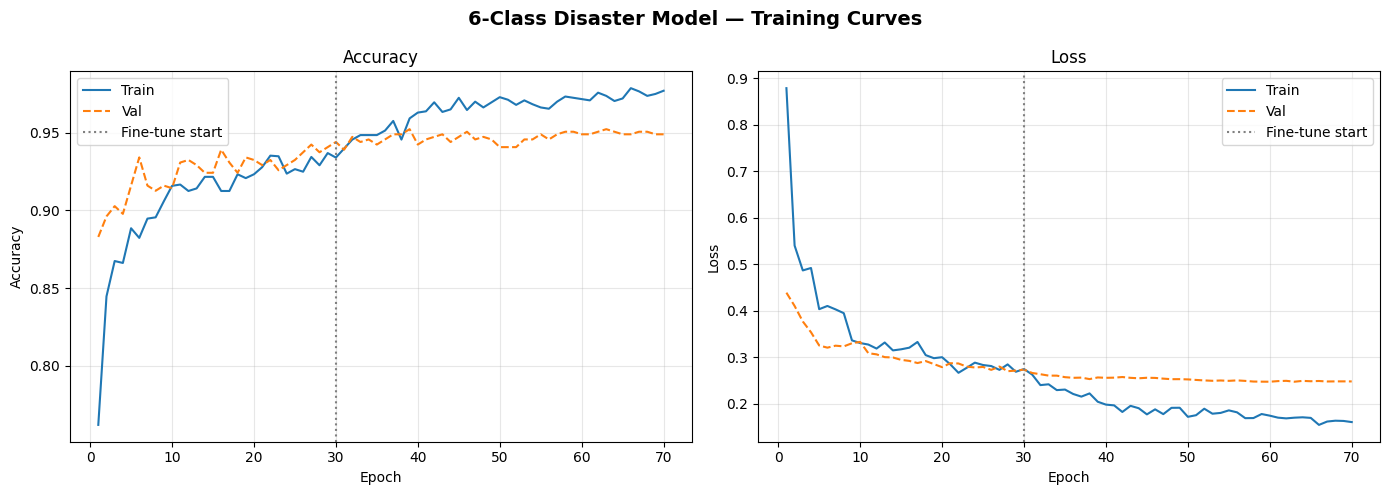

Saved: training_curves.png


In [ ]:

def plot_training_curves(h1, h2):
    def concat(key):
        return h1.history.get(key, []) + h2.history.get(key, [])

    acc      = concat("accuracy")
    val_acc  = concat("val_accuracy")
    loss     = concat("loss")
    val_loss = concat("val_loss")
    epochs   = range(1, len(acc) + 1)
    p1_end   = len(h1.history.get("accuracy", []))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("6-Class Disaster Model — Training Curves",
                 fontsize=14, fontweight="bold")

    for ax, metric, val_metric, ylabel in [
        (axes[0], acc,  val_acc,  "Accuracy"),
        (axes[1], loss, val_loss, "Loss"),
    ]:
        ax.plot(epochs, metric,     label="Train")
        ax.plot(epochs, val_metric, label="Val", linestyle="--")
        if p1_end < len(acc):
            ax.axvline(p1_end, color="grey", linestyle=":", label="Fine-tune start")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Saved: training_curves.png")


plot_training_curves(hist_p1, hist_p2)


In [ ]:
print(f"\n{'═'*65}")
print("  EVALUATION — Test Set")
print(f"{'═'*65}")

y_prob = model.predict(test_ds, verbose=1)          # shape (N, 6)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_labels_arr

# ── Per-class & overall metrics ───────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_true, y_pred,    average="weighted", zero_division=0)
f1   = f1_score(y_true, y_pred,        average="weighted", zero_division=0)

print(f"  Weighted Accuracy  : {acc:.4f}")
print(f"  Weighted Precision : {prec:.4f}")
print(f"  Weighted Recall    : {rec:.4f}")
print(f"  Weighted F1 Score  : {f1:.4f}")



═════════════════════════════════════════════════════════════════
  EVALUATION — Test Set
═════════════════════════════════════════════════════════════════
38/38 ━━━━━━━━━━━━━━━━━━━━ 52s 940ms/step

Classification Report:
                 precision    recall  f1-score   support

   Damaged Road       0.97      0.96      0.96       201
    Normal Road       0.95      0.98      0.96       199
   Damaged Home       0.90      0.95      0.92       203
Normal Building       0.97      0.90      0.93       200
      Big Trash       0.94      0.92      0.93       203
    Small Trash       0.93      0.95      0.94       207

       accuracy                           0.94      1213
      macro avg       0.94      0.94      0.94      1213
   weighted avg       0.94      0.94      0.94      1213

  Weighted Accuracy  : 0.9415
  Weighted Precision : 0.9423
  Weighted Recall    : 0.9415
  Weighted F1 Score  : 0.9415
